In [1]:
import os

# Keep backend selection as-is (core logic unchanged).
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import numpy as np
import pandas as pd
import cv2  # kept as in original
from keras.preprocessing import image
from keras import optimizers
from keras import layers, models
from keras.applications.imagenet_utils import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns  # kept as in original


def _pick_existing_path(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"None of these paths exist: {candidates}")


# Fix: prefer the actual dataset root; avoid listing that can break if INPUT_BASE resolves oddly.
INPUT_BASE = _pick_existing_path(
    [
        "/kaggle/input/aerial-cactus-identification",
        "../input/aerial-cactus-identification",
        "/kaggle/data/aerial-cactus-identification",
        "/kaggle/input",
        "../input",
    ]
)

print("Using INPUT_BASE:", INPUT_BASE)



2026-01-12 23:14:45.177273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768259685.190980      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768259685.195194      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-12 23:14:45.213246: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using INPUT_BASE: /kaggle/input/aerial-cactus-identification


In [2]:
# Fix: directory selection should point at folders that actually contain images.
# The previous code preferred train/train and test/test, which doesn't exist in this dataset layout.
train_dir = _pick_existing_path(
    [
        os.path.join(INPUT_BASE, "train"),
        os.path.join(INPUT_BASE, "aerial-cactus-identification", "train"),
    ]
)

test_dir = _pick_existing_path(
    [
        os.path.join(INPUT_BASE, "test"),
        os.path.join(INPUT_BASE, "aerial-cactus-identification", "test"),
    ]
)

train_csv_path = _pick_existing_path(
    [
        os.path.join(INPUT_BASE, "train.csv"),
        os.path.join(INPUT_BASE, "aerial-cactus-identification", "train.csv"),
        "../input/train.csv",
        "/kaggle/input/train.csv",
    ]
)

sample_sub_path = _pick_existing_path(
    [
        os.path.join(INPUT_BASE, "sample_submission.csv"),
        os.path.join(
            INPUT_BASE, "aerial-cactus-identification", "sample_submission.csv"
        ),
        "../input/sample_submission.csv",
        "/kaggle/input/sample_submission.csv",
    ]
)

train = pd.read_csv(train_csv_path)
df_test = pd.read_csv(sample_sub_path)

print("train_dir:", train_dir)
print("test_dir:", test_dir)
print("train_csv_path:", train_csv_path)
print("sample_sub_path:", sample_sub_path)
print("Train rows:", train.shape, "Test rows:", df_test.shape)



train_dir: /kaggle/input/aerial-cactus-identification/train
test_dir: /kaggle/input/aerial-cactus-identification/test
train_csv_path: /kaggle/input/aerial-cactus-identification/train.csv
sample_sub_path: /kaggle/input/aerial-cactus-identification/sample_submission.csv
Train rows: (14175, 2) Test rows: (3325, 2)


In [3]:
train.head(5)



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [4]:
print("out dataset has {} rows and {} columns".format(train.shape[0], train.shape[1]))



out dataset has 14175 rows and 2 columns


In [5]:
train["has_cactus"].value_counts()



has_cactus
1    10628
0     3547
Name: count, dtype: int64

In [6]:
print("The number of rows in test set is %d" % (len(os.listdir(test_dir))))



The number of rows in test set is 3326


In [7]:
# Fix: Remove IPython.display.Image usage that triggered runtime error in this environment.
# Instead, just sanity-check that the first file exists.
first_img_path = os.path.join(train_dir, train.iloc[0, 0])
print("First train image path:", first_img_path)
print("Exists:", os.path.exists(first_img_path))




First train image path: /kaggle/input/aerial-cactus-identification/train/2de8f189f1dce439766637e75df0ee27.jpg
Exists: True


In [8]:
def prepare_data(data, m, direc):
    print("preparing data")
    X_train = np.zeros((m, 150, 150, 3), dtype=np.float32)
    count = 0
    for fig in data["id"]:
        img_path = os.path.join(direc, fig)
        img = image.load_img(img_path, target_size=(150, 150))
        x = image.img_to_array(img)
        x = preprocess_input(x)
        X_train[count] = x / 255.0
        count += 1
    print("Done")
    return X_train




In [9]:
data = prepare_data(train, train.shape[0], train_dir)
test = prepare_data(df_test, len(df_test), test_dir)



preparing data
Done
preparing data
Done


In [10]:
# Fix: avoid hard-coded split index that can create empty/odd splits; keep semantics (simple holdout split).
m = data.shape[0]
split_idx = int(m * 0.85)

X_train = data[:split_idx]
y_train = train["has_cactus"].iloc[:split_idx].to_numpy()

valid = data[split_idx:]
y_valid = train["has_cactus"].iloc[split_idx:].to_numpy()

print("Train split:", X_train.shape, y_train.shape)
print("Valid split:", valid.shape, y_valid.shape)



Train split: (12048, 150, 150, 3) (12048,)
Valid split: (2127, 150, 150, 3) (2127,)


In [11]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape=(150, 150, 3)))
model.add(layers.MaxPool2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-12 23:15:01.325580: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768259701.326038      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


In [12]:
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,585 (2.49 MB)

 Trainable params: 651,585 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    loss="binary_crossentropy", optimizer=optimizers.RMSprop(), metrics=["acc"]
)



In [14]:
epochs = 10
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(valid, y_valid))



Epoch 1/10


I0000 00:00:1768259707.735786      68 service.cc:148] XLA service 0x7fb65400abb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768259707.735829      68 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-12 23:15:07.760387: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768259707.881312      68 cuda_dnn.cc:529] Loaded cuDNN version 90300


 22/377 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.6778 - loss: 0.6502

I0000 00:00:1768259709.301357      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


377/377 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - acc: 0.8601 - loss: 0.3192 - val_acc: 0.9544 - val_loss: 0.1012
Epoch 2/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9581 - loss: 0.1088 - val_acc: 0.9812 - val_loss: 0.0638
Epoch 3/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9707 - loss: 0.0753 - val_acc: 0.9699 - val_loss: 0.1107
Epoch 4/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9775 - loss: 0.0613 - val_acc: 0.9859 - val_loss: 0.0442
Epoch 5/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9844 - loss: 0.0467 - val_acc: 0.9807 - val_loss: 0.0696
Epoch 6/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9866 - loss: 0.0400 - val_acc: 0.9882 - val_loss: 0.0355
Epoch 7/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9905 - loss: 0.0294 - val_acc: 0.9835 - val_loss: 0.0455
Epoch 8/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9929 - loss: 0.0213 - val_acc: 0.9892 - val_loss: 0.0360
Epoch 9/10
377/377 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9940 

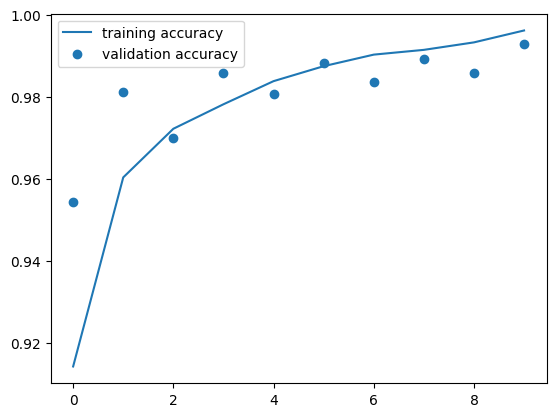

In [15]:
# Fix: handle metric key name differences across keras versions ('acc' vs 'accuracy').
hist = history.history
acc_key = "acc" if "acc" in hist else "accuracy"
val_acc_key = "val_acc" if "val_acc" in hist else "val_accuracy"

acc = hist[acc_key]
epochs_ = range(0, epochs)
plt.plot(epochs_, acc, label="training accuracy")

acc_val = hist[val_acc_key]
plt.scatter(list(epochs_), acc_val, label="validation accuracy")
plt.legend()
plt.show()



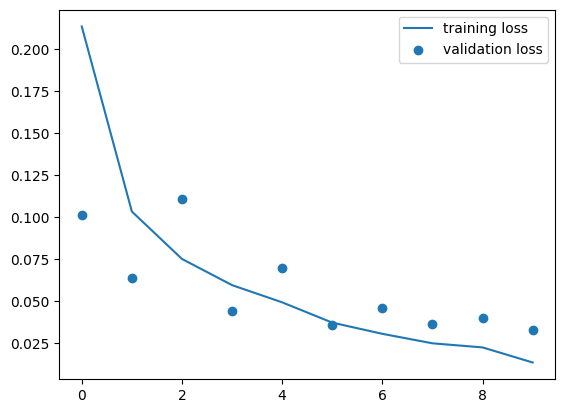

In [16]:
loss = history.history["loss"]
epochs_ = range(0, epochs)
plt.plot(epochs_, loss, label="training loss")

loss_val = history.history["val_loss"]
plt.scatter(list(epochs_), loss_val, label="validation loss")
plt.legend()
plt.show()



In [17]:
y_pre = model.predict(test, batch_size=64, verbose=1).reshape(-1)

df = pd.DataFrame({"id": df_test["id"]})
df["has_cactus"] = y_pre.astype(float)

# Ensure a valid submission filename with .csv suffix.
out_path = "submission.csv"
df.to_csv(out_path, index=False)

print(df.head())
print("Wrote", out_path, "with shape:", df.shape)
print("Submission columns:", df.columns.tolist())

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         1.0
1  134f04305c795d6d202502c2ce3578f3.jpg         1.0
2  41fad8d145e6c41868ce3617e30a2545.jpg         1.0
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         1.0
4  b77dc902b035887cbbc01920ce0e3151.jpg         1.0
Wrote submission.csv with shape: (3325, 2)
Submission columns: ['id', 'has_cactus']
